In [8]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import time
from collections import defaultdict
import statsmodels.api as sm
from statsmodels.genmod.families import links 
from statsmodels.api import Logit
import statsmodels.formula.api as smf
from statsmodels.formula.api import glm
from statsmodels.formula.api import ols
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings("ignore")

#prereq = "para trabajar pre req progv22025-09-15095342_procesado.xlsx"
#historial = "detalle matricula cohorte 2019.xlsx"
historial = "historia_todos.csv"

                                

In [9]:
## Crear DataFrame con los nombres de las asignaturas y sus códigos

def crear_df_asignaturas(df_historial: pd.DataFrame) -> pd.DataFrame:
    # Extraer las columnas relevantes
    df_asignaturas = df_historial[['Cod materia curso', 'Descripcion_Materia']].drop_duplicates()
    
    # Eliminar filas con valores nulos en 'Cod materia curso' o 'Descripcion_Materia'
    df_asignaturas = df_asignaturas.dropna(subset=['Cod materia curso', 'Descripcion_Materia'])
    
    # Eliminar espacios en blanco al inicio y al final de los nombres de las asignaturas
    df_asignaturas['Descripcion_Materia'] = df_asignaturas['Descripcion_Materia'].str.strip()
    
    # Eliminar duplicados basados en 'Cod materia curso', manteniendo la primera ocurrencia
    df_asignaturas = df_asignaturas.drop_duplicates(subset=['Cod materia curso'], keep='first')
    
    # Ordenar el DataFrame por 'Cod materia curso'
    df_asignaturas = df_asignaturas.sort_values(by='Cod materia curso').reset_index(drop=True)

    print(f"👌 Creado DataFrame con las asignaturas unicas y sus nombres. Número de asignaturas únicas: {len(df_asignaturas)}")
    
    return df_asignaturas

In [10]:
## Añadir numero de intentos por asignatura

def calcular_num_intentos(df: pd.DataFrame) -> pd.DataFrame:
    # Paso 1: quedarse con intentos únicos por periodo
    df_unique = df[['Pidm', 'Cod materia curso', 'Periodo']].drop_duplicates()

    # Paso 2: ordenar por periodo
    df_unique = df_unique.sort_values(['Pidm', 'Cod materia curso', 'Periodo'])

    # Paso 3: generar número de intento acumulado
    # rank(method='dense') da consecutivos (1,2,3..) por periodo distinto
    df_unique['num_intentos_asignatura'] = (
        df_unique.groupby(['Pidm', 'Cod materia curso']).cumcount() + 1
    )

    # Paso 4: hacer merge con el dataframe original
    df_result = df.merge(
        df_unique,
        on=['Pidm', 'Cod materia curso', 'Periodo'],
        how='left'
    )

    return df_result

In [11]:
## Funciones de limpieza del DataFrame

def arreglar_comas_por_puntos(df: pd.DataFrame, cols_excluir: list) -> pd.DataFrame:
    """
    Reemplaza comas (,) por puntos (.) en todas las columnas tipo string,
    excepto en las columnas listadas en cols_excluir.
    Intenta convertir los valores resultantes a float.
    """
    for col in df.columns:
        if col not in cols_excluir and df[col].dtype == object:
            df[col] = df[col].str.replace(",", ".", regex=False)
            # Intentar conversión a float cuando sea posible
            try:
                df[col] = df[col].astype(float)
            except ValueError:
                pass  # si no se puede convertir, se queda como string
            print(f"[Comas→Puntos] Procesada columna: {col}")
        elif col in cols_excluir:
            print(f"[Comas→Puntos] Columna excluida: {col}")
    return df


def imputar_valores(df: pd.DataFrame) -> pd.DataFrame:
    """Imputa valores en columnas específicas."""
    # Columna repitencia → vacíos a 0.0
    col_repitencia = "_ Matricula detalle para analisis.repitencia profesor referencia"
    if col_repitencia in df.columns:
        antes = df[col_repitencia].isna().sum()
        df[col_repitencia] = df[col_repitencia].fillna(0).astype(float)
        despues = df[col_repitencia].isna().sum()
        print(f"[Imputación] Columna '{col_repitencia}': {antes} vacíos reemplazados por 0.0")

    # Columna Procedencia Categoria → reemplazar "6 No registra" por NaN
    col_procedencia = "_ Matricula detalle para analisis.Procedencia Categoria"
    if col_procedencia in df.columns:
        conteo = (df[col_procedencia] == "6 No registra").sum()
        df[col_procedencia] = df[col_procedencia].replace("6 No registra", np.nan)
        print(f"[Imputación] Columna '{col_procedencia}': {conteo} valores '6 No registra' reemplazados por NaN")

    # Columna Sexo → reemplazar -99 por NaN
    col_sexo = "_ Matricula detalle para analisis.Sexo"
    if col_sexo in df.columns:
        conteo = (df[col_sexo] == -99).sum()
        df[col_sexo] = df[col_sexo].replace(-99, np.nan)
        print(f"[Imputación] Columna '{col_sexo}': {conteo} valores '-99' reemplazados por NaN")

    # Columna Calificacion_Final → vacíos a -1
    col_nota_final = "Calificacion_Final"
    if col_nota_final in df.columns:
        conteo = df[col_nota_final].isna().sum()
        df[col_nota_final] = df[col_nota_final].fillna(-1).astype(float)
        print(f"[Imputación] Columna '{col_nota_final}': {conteo} vacíos reemplazados por -1")

    # Añadir columna de numero de intentos asignatura
    df = calcular_num_intentos(df)
    print(f"[Imputación] Columna num_intentos_asignatura': usando funcion calcular_num_intentos")

    return df


def eliminar_columnas_vacias(df: pd.DataFrame, columnas_eliminadas: list) -> pd.DataFrame:
    """Elimina columnas 100% vacías."""
    cols_vacias = df.columns[df.isna().all()].tolist()
    if cols_vacias:
        df = df.drop(columns=cols_vacias)
        columnas_eliminadas.extend(cols_vacias)
        print(f"[Columnas] Eliminadas columnas vacías: {cols_vacias}")
    else:
        print("[Columnas] No se encontraron columnas totalmente vacías")
    return df


def eliminar_filas_por_columna(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """Elimina filas con nulos en columnas con <20% vacíos."""
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)

    for col in df.columns:
        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print(f"[Filas] Columna '{col}': {porcentaje:.2%} nulos → eliminadas {eliminadas} filas")
        else:
            print(f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (≥20%), no se eliminaron filas")

    filas_finales = len(df)
    print(f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} → {filas_finales})")

    return df, filas_eliminadas_total

def eliminar_filas_por_columna_ignorando_col_prereq(df: pd.DataFrame) -> tuple[pd.DataFrame, int]:
    """
    Elimina filas con nulos en columnas con <20% vacíos,
    ignorando las columnas que siguen el patrón Prereq_i_[Atributo].
    """
    filas_eliminadas_total = 0
    total_filas_inicial = len(df)

    for col in df.columns:
        # Ignorar columnas de prerequisitos
        if col.startswith("Prereq_"):
            print(f"[Ignorado] Columna '{col}' pertenece a prerequisitos, no se revisa.")
            continue

        nulos = df[col].isna().sum()
        porcentaje = nulos / len(df) if len(df) > 0 else 0

        if porcentaje == 0:
            continue

        if porcentaje < 0.20:
            filas_antes = len(df)
            df = df.dropna(subset=[col])
            filas_despues = len(df)
            eliminadas = filas_antes - filas_despues
            filas_eliminadas_total += eliminadas
            print(f"[Filas] Columna '{col}': {porcentaje:.2%} nulos → eliminadas {eliminadas} filas")
        else:
            print(f"[Aviso] Columna '{col}' tiene {porcentaje:.2%} de valores nulos (≥20%), no se eliminaron filas")

    filas_finales = len(df)
    print(f"[Filas] Total eliminadas: {filas_eliminadas_total} (de {total_filas_inicial} → {filas_finales})")

    return df, filas_eliminadas_total



def limpiar_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Función principal que limpia el dataframe según reglas definidas."""
    print("=== Iniciando limpieza del DataFrame ===")

    # Imputación de valores
    df = imputar_valores(df)

    # Eliminar columnas vacías
    columnas_eliminadas = []
    df = eliminar_columnas_vacias(df, columnas_eliminadas)

    # Eliminar filas según condición por columnas
    #df, filas_eliminadas = eliminar_filas_por_columna(df)
    df, filas_eliminadas = eliminar_filas_por_columna_ignorando_col_prereq(df)
    
    # Resumen final
    print("\n=== Resumen limpieza ===")
    print(f"Filas eliminadas: {filas_eliminadas}")
    print(f"Columnas eliminadas: {columnas_eliminadas}")

    return df


In [12]:
#Renombrar Columnas

def renombrar_columnas(df: pd.DataFrame):
    """
    Renombra columnas largas por versiones cortas en snake_case.
    Devuelve:
      - DataFrame con columnas renombradas
      - Lista con columnas finales de análisis (col_usar renombradas)
      - String con el nombre de la variable objetivo renombrada
    """

    # Mapeo de nombres originales a nuevos
    mapping = {
        "_ Matricula detalle para analisis.repitencia profesor referencia": "repitencia_prof_ref",
        "Nombre_Programa": "programa",
        "_ Matricula detalle para analisis.Prof_Codigo": "profesor_codigo",
        "_ Matricula detalle para analisis.pga inicial": "pga_inicial",
        "_ Matricula detalle para analisis.prom semestral t_1": "promedio_sem_t1",
        "_ Matricula detalle para analisis.Sexo": "sexo",
        "_ Matricula detalle para analisis.Asistencia CREE t_1": "asistencia_cree_t1",
        "_ Matricula detalle para analisis.Procedencia Categoria": "procedencia_categoria",
        "_ Matricula detalle para analisis.Edad cursan asignatura": "edad_curso",
        "_ Matricula detalle para analisis.Calif Final _ Retiros": "resultado_final",
        "Estado asignatura": "estado_asignatura"
    }

    # Renombrar columnas
    df = df.rename(columns=mapping)

    # Construir lista final de columnas de análisis
    col_usar = [
        "repitencia_prof_ref",
        "programa",
        "profesor_codigo",
        "pga_inicial",
        "promedio_sem_t1",
        "sexo",
        "asistencia_cree_t1",
        "procedencia_categoria",
        "edad_curso",
        "num_intentos_asignatura"
    ]


    df["aprobacion_asignatura_binario"] = df["estado_asignatura"].apply(lambda x: 1 if x == "APROBADA" else 0)

    # Variable objetivo
    var_objetivo = "aprobacion_asignatura_binario"

    return df, col_usar, var_objetivo


In [ ]:
## Indentificar columnas de prerequisitos válidas

def columnas_prereq_validas(df: pd.DataFrame, umbral: float = 0.8) -> tuple[pd.DataFrame, list]:
    """
    Identifica las columnas de prerequisitos (Nota e Intentos) que cumplen con tener
    al menos un 80% de valores no nulos en la columna Nota.
    Además, elimina del DataFrame las filas que tengan NaN en esas columnas seleccionadas.
    
    Parámetros:
        df: DataFrame de entrada
        umbral: proporción mínima de valores no nulos (default=0.8)
    
    Retorna:
        - DataFrame sin filas NaN en las columnas seleccionadas
        - Lista con las columnas Prereq_i_Nota y Prereq_i_Intentos que cumplen el criterio
    """
    columnas_seleccionadas = []
    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")

        if col_intentos not in df.columns:
            print(f"[Aviso] No se encontró la columna de intentos para {col_nota}, se omite el par.")
            continue

        total = len(df)
        no_nulos = df[col_nota].notna().sum()
        proporcion = no_nulos / total if total > 0 else 0

        if proporcion >= umbral:
            columnas_seleccionadas.extend([col_nota, col_intentos])
            print(f"[Incluido] {col_nota} y {col_intentos} → {proporcion:.2%} valores válidos")
        else:
            print(f"[Excluido] {col_nota} y {col_intentos} → {proporcion:.2%} valores válidos (<{umbral:.0%})")

    # Eliminar filas con NaN en las columnas seleccionadas
    df_filtrado = df.copy()
    if columnas_seleccionadas:
        filas_antes = len(df_filtrado)
        df_filtrado = df_filtrado.dropna(subset=columnas_seleccionadas)
        filas_despues = len(df_filtrado)
        eliminadas = filas_antes - filas_despues
        print(f"\n[Filtrado] Se eliminaron {eliminadas} filas con NaN en {columnas_seleccionadas}")
    else:
        print("\n[Filtrado] No se seleccionaron columnas, no se eliminaron filas.")

    print("\nResumen final:")
    print(f"Columnas seleccionadas: {columnas_seleccionadas}")

    return df_filtrado, columnas_seleccionadas

## Identificar columnas de prerequisitos válidas (versión 2) Con cambio de nombre!

import unicodedata

def normalizar_nombre(nombre: str) -> str:
    """
    Convierte un nombre en snake_case sin acentos, dejando los números intactos.
    """
    # Eliminar acentos
    nombre = ''.join(
        c for c in unicodedata.normalize('NFD', nombre)
        if unicodedata.category(c) != 'Mn'
    )
    # Reemplazar espacios y caracteres raros por "_", pero dejar letras y números
    nombre = re.sub(r'[^a-zA-Z0-9]+', '_', nombre)
    # Pasar a minúsculas
    nombre = nombre.strip("_").lower()
    return nombre

def columnas_prereq_validas_ext(df: pd.DataFrame, nombres_asignaturas: pd.DataFrame, umbral: float = 0.8):
    """
    Identifica columnas de prerequisitos que cumplen con el umbral de no-nulos
    y crea nuevas columnas con el nombre de la asignatura.

    Parámetros:
        df: DataFrame de entrada (con columnas Prereq_i_Nota y Prereq_i_Codigo)
        nombres_asignaturas: DataFrame con columnas ["Cod materia curso", "Descripcion_Materia"]
        umbral: proporción mínima de valores no nulos en la columna Nota (default=0.8)

    Retorna:
        columnas_nuevas (list): Lista con los nombres de las nuevas columnas creadas
        df_modificado (pd.DataFrame): DataFrame con las columnas nuevas añadidas
    """
    columnas_nuevas = []
    columnas_seleccionadas = []
    df_modificado = df.copy()

    prereq_notas = [c for c in df.columns if c.startswith("Prereq_") and c.endswith("_Nota")]

    for col_nota in prereq_notas:
        col_intentos = col_nota.replace("_Nota", "_Intentos")
        col_codigo = col_nota.replace("_Nota", "_Codigo")

        if col_intentos not in df.columns:
            print(f"[Aviso] No se encontró la columna de intentos para {col_nota}, se omite el par.")
            continue
        if col_codigo not in df.columns:
            print(f"[Aviso] No se encontró la columna de código para {col_nota}, se omite el par.")
            continue

        total = len(df)
        no_nulos = df[col_nota].notna().sum()
        proporcion = no_nulos / total if total > 0 else 0

        if proporcion >= umbral:
            # Procesar cada fila: buscar nombre de la materia
            nuevas_columnas_temp = []
            for idx, codigo in df.loc[df[col_codigo].notna(), col_codigo].items():
                # Buscar en nombres_asignaturas
                nombre_match = nombres_asignaturas.loc[
                    nombres_asignaturas["Cod materia curso"] == codigo, 
                    "Descripcion_Materia"
                ]
                if not nombre_match.empty:
                    nombre_materia = nombre_match.values[0]
                else:
                    nombre_materia = codigo  # fallback

                # Normalizar nombre
                nombre_materia_norm = normalizar_nombre(str(nombre_materia))
                nueva_columna = f"Prereq_{nombre_materia_norm}_Nota"

                # Crear la columna si no existe
                if nueva_columna not in df_modificado.columns:
                    df_modificado[nueva_columna] = pd.NA

                # Asignar el valor de la nota, asegurando tipo float
                valor_nota = df.loc[idx, col_nota]
                try:
                    valor_nota_float = float(valor_nota)
                except (ValueError, TypeError):
                    valor_nota_float = pd.NA
                df_modificado.at[idx, nueva_columna] = valor_nota_float

                # Forzar tipo float en la columna creada (puede tener <NA>)
                df_modificado[nueva_columna] = pd.to_numeric(df_modificado[nueva_columna], errors='coerce')

                nuevas_columnas_temp.append(nueva_columna)

                # Añadir columna de numero de intentos asociados
                nueva_columna_intentos = f"Prereq_{nombre_materia_norm}_Intentos"
                if nueva_columna_intentos not in df_modificado.columns:
                    df_modificado[nueva_columna_intentos] = pd.NA

                valor_intentos = df.loc[idx, col_intentos]
                try:
                    valor_intentos_float = float(valor_intentos)
                except (ValueError, TypeError):
                    valor_intentos_float = pd.NA
                df_modificado.at[idx, nueva_columna_intentos] = valor_intentos_float

                # Forzar tipo int en la columna de intentos (puede tener <NA>)
                df_modificado[nueva_columna_intentos] = pd.to_numeric(df_modificado[nueva_columna_intentos], errors='coerce')
                
                nuevas_columnas_temp.append(nueva_columna_intentos)

            # Agregar solo las columnas únicas de esta ronda
            columnas_nuevas.extend(list(set(nuevas_columnas_temp)))

            print(f"[Incluido] {col_nota} y {col_intentos} → {proporcion:.2%} válidos → nuevas columnas creadas.")
        else:
            print(f"[Excluido] {col_nota} y {col_intentos} → {proporcion:.2%} válidos (<{umbral:.0%})")

    print("\nResumen final:")
    print(f"Columnas nuevas seleccionadas: {columnas_nuevas}")

    # Eliminar filas con NaN en las columnas seleccionadas
    columnas_seleccionadas = columnas_nuevas.copy()
    if columnas_seleccionadas:
        filas_antes = len(df_modificado)
        df_modificado = df_modificado.dropna(subset=columnas_seleccionadas)
        filas_despues = len(df_modificado)
        eliminadas = filas_antes - filas_despues
        print(f"\n[Filtrado] Se eliminaron {eliminadas} filas con NaN en {columnas_seleccionadas}")
    else:
        print("\n[Filtrado] No se seleccionaron columnas, no se eliminaron filas.")

    return  df_modificado,columnas_nuevas


In [14]:
## ONE HOT

import random

import random

def aplicar_one_hot(df: pd.DataFrame, cols: list, drop_random: bool = True) -> tuple[pd.DataFrame, list]:
    """
    Aplica one-hot encoding sobre columnas específicas,
    reemplazando las originales con sus dummies.
    Para evitar multicolinealidad, elimina aleatoriamente una dummy por variable.
    Además, solo incluye en la lista de salida las columnas dummies que
    tengan al menos un 10% de registros con valor 1.
    
    Parámetros:
        df: DataFrame de entrada
        cols: lista de columnas a transformar
        drop_random: si True, elimina aleatoriamente una dummy de cada variable
    
    Retorna:
        - DataFrame con columnas dummies reemplazando las originales
        - Lista con las columnas nuevas creadas (sin la eliminada y filtradas por ≥10%)
    """
    df = df.copy()
    nuevas_columnas = []

    for col in cols:
        if col not in df.columns:
            print(f"[Aviso] Columna '{col}' no existe en el DataFrame, se omite.")
            continue

        # Generar dummies (ignorar NaN, codificar en 0/1)
        dummies = pd.get_dummies(df[col], prefix=col, dummy_na=False).astype(int)

        # Drop aleatorio de una columna dummy (para evitar multicolinealidad)
        if drop_random and len(dummies.columns) > 1:
            col_drop = random.choice(dummies.columns.tolist())
            dummies = dummies.drop(columns=[col_drop])
            print(f"[OneHot] Columna '{col}' → eliminada aleatoriamente '{col_drop}' para evitar multicolinealidad")

        # Reemplazar columna original por las nuevas dummies
        df = df.drop(columns=[col]).join(dummies)

        # Revisar el porcentaje de "1s" en cada dummy
        cols_validas = []
        for dummy in dummies.columns:
            proporcion = dummies[dummy].sum() / len(dummies)
            if proporcion >= 0.10:
                cols_validas.append(dummy)
            else:
                print(f"[Filtro] Columna '{dummy}' no incluida en la lista (solo {proporcion:.2%} en 1s)")

        # Guardar solo las columnas válidas
        nuevas_columnas.extend(cols_validas)

        print(f"[OneHot] Columna '{col}' → creadas {len(dummies.columns)} columnas, válidas: {cols_validas}")

    return df, nuevas_columnas




In [15]:
#Cambiar a category

def cambiar_a_category(df, cols):
    # Convierte columnas a category si existen

    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype("category")
        else:
            print(f"Columna no encontrada: {c}")

    # Verificar tipos resultantes
    print(df[ [c for c in cols if c in df.columns] ].dtypes)  

    return df


    

In [16]:
# Entrenar_xgboost_regresion

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

def entrenar_xgboost_regresion(df, columna_objetivo, columnas_predictores):
    """
    Entrena un modelo XGBoost de regresión sobre un dataframe.

    Parámetros:
        df (pd.DataFrame): DataFrame con los datos
        columna_objetivo (str): Nombre de la columna a predecir
        columnas_predictores (list): Lista con nombres de columnas de entrada

    Retorna:
        modelo (XGBRegressor): Modelo entrenado
        df_resultados (pd.DataFrame): DataFrame original con columna de predicciones
        metricas (dict): RMSE, MAE, R2
    """

    # Separar variables
    X = df[columnas_predictores]
    y = df[columna_objetivo]

    # Dividir en train (80%) y test (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Definir modelo
    modelo = XGBRegressor(
        objective="reg:squarederror",
        enable_categorical=True,
        random_state=42
    )

    # Entrenar
    modelo.fit(X_train, y_train)

    # Predicciones en test
    y_pred = modelo.predict(X_test)

    # Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metricas = {"RMSE": rmse, "MAE": mae, "R2": r2}

    # Mostrar métricas como tabla
    print("\n📊 Métricas de evaluación del modelo:\n")
    print(pd.DataFrame(metricas, index=["Valores"]).T)

    # Agregar columna de predicciones al df
    df_resultados = df.copy()
    df_resultados["Prediccion_XGB"] = modelo.predict(X)

    return modelo, df_resultados, metricas, X_train, X_test


In [17]:
# mostrar_arbol & mostrar_importancia_gain & reporte_importancia

from xgboost import plot_tree
import matplotlib.pyplot as plt
from xgboost import plot_importance

def mostrar_arbol(modelo, num_tree=0, ancho=40, alto=20, orientacion="LR"):
    """
    Muestra el árbol de decisión generado por XGBoost.

    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        num_tree (int): Índice del árbol a graficar
        ancho (int): Ancho de la figura
        alto (int): Alto de la figura
        orientacion (str): Dirección del árbol ("LR"=izq-der, "TB"=arriba-abajo)
    """
    plt.figure(figsize=(ancho, alto))
    plot_tree(modelo, num_trees=num_tree, rankdir=orientacion)
    plt.show()


def mostrar_importancia_gain(modelo, top_n=20):
    """
    Muestra la importancia de las variables en el modelo.
    
    Parámetros:
        modelo (XGBRegressor): Modelo entrenado
        top_n (int): Número de variables a mostrar
    """
    plt.figure(figsize=(10,6))
    plot_importance(modelo, importance_type="gain", max_num_features=top_n, height=0.5)
    plt.title("Importancia de variables (gain)")
    plt.show()


def reporte_importancia(modelo):
    """
    Genera un reporte tabulado de importancia de variables
    con métricas: gain, weight y cover.
    """
    booster = modelo.get_booster()

    # Obtener cada métrica como diccionario
    importancia_gain = booster.get_score(importance_type="gain")
    importancia_weight = booster.get_score(importance_type="weight")
    importancia_cover = booster.get_score(importance_type="cover")

    # Convertir a DataFrame
    df_gain = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    df_weight = pd.DataFrame.from_dict(importancia_weight, orient="index", columns=["Weight"])
    df_cover = pd.DataFrame.from_dict(importancia_cover, orient="index", columns=["Cover"])

    # Unir todo
    df_importancia = df_gain.join(df_weight).join(df_cover)

    # Ordenar por Gain
    df_importancia = df_importancia.sort_values("Gain", ascending=False)

    print("\n📊 Reporte de Importancia de Variables (XGBoost)\n")
    print(df_importancia)

    return df_importancia


In [18]:
#matriz_confusion

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def matriz_confusion_personalizada(df, columna_objetivo, columna_prediccion, margen_error=0.2, graficar=True):
    """
    Construye una matriz de confusión personalizada basada en un margen de error.

    Parámetros:
        df (pd.DataFrame): DataFrame con columna real y predicción
        columna_objetivo (str): Nombre de la columna real
        columna_prediccion (str): Nombre de la columna de predicciones
        margen_error (float): Margen permitido para considerar la predicción correcta
        graficar (bool): Si True, muestra la matriz de confusión en gráfico

    Retorna:
        matriz (np.ndarray): Matriz de confusión
        df_resultados (pd.DataFrame): DataFrame con columna de éxito (1 o 0)
    """

    # Copiar para no alterar el original
    df_resultados = df.copy()

    # Redondear predicciones a 2 decimales
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].round(2)

    # Convertir cualquier valor < 0 en -1
    df_resultados[columna_prediccion] = df_resultados[columna_prediccion].apply(lambda x: -1 if x < 0 else x)

    # Crear etiqueta de éxito: 1 si la diferencia es <= margen_error
    df_resultados["Exito"] = np.where(
        abs(df_resultados[columna_objetivo] - df_resultados[columna_prediccion]) <= margen_error, 
        1, 
        0
    )

    # Etiqueta real: siempre 1 (correcto) porque evaluamos predicciones
    # Aquí podemos definir "ground truth" como si el valor real fuera siempre válido
    # entonces comparamos con éxito/fallo de predicción
    y_true = np.ones(len(df_resultados))   # todos deberían ser "correctos"
    y_pred = df_resultados["Exito"]

    # Calcular matriz de confusión
    matriz = confusion_matrix(y_true, y_pred, labels=[1,0])
    print(classification_report(y_true, y_pred))

    if graficar:
        disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Éxito", "Fallo"])
        disp.plot(cmap="Blues")
        plt.title("Matriz de Confusión Personalizada")
        plt.show()

    return matriz, df_resultados


In [19]:
#shap

import shap 

def interpretar_xgboost_shap(modelo, X, columnas_predictores, top_n=5, id_check=0):
    """
    Genera interpretaciones SHAP para un modelo XGBoost:
    - Summary plot (impacto global de las variables)
    - Dependence plots para las N variables más importantes

    Parámetros:
        modelo: XGBRegressor ya entrenado
        X (pd.DataFrame): datos (X_train o X_test)
        columnas_predictores (list): lista con nombres de variables
        top_n (int): número de variables más importantes a mostrar en dependence plots
    """
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    # --- 1. Summary plot ---
    print("📊 Generando summary plot global...")
    shap.summary_plot(shap_values, X, feature_names=columnas_predictores)

    # --- 2. Dependence plots ---
    print(f"\n📊 Generando dependence plots para las {top_n} variables más importantes...\n")
    
    # Obtener importancia (gain) desde XGBoost
    importancia_gain = modelo.get_booster().get_score(importance_type="gain")
    importancia_df = pd.DataFrame.from_dict(importancia_gain, orient="index", columns=["Gain"])
    importancia_df = importancia_df.sort_values("Gain", ascending=False).head(top_n)

    for feature in importancia_df.index:
        print(f"➡️ Dependence plot para variable: {feature}")
        shap.dependence_plot(feature, shap_values.values, X, feature_names=columnas_predictores)

    i = id_check  # índice del estudiante en X_test
    print(f"📌 Explicación de la predicción para el estudiante {i}")
    shap.plots.waterfall(shap_values[i]) 

def gen_xboost_waterfall_plot(modelo, X, id_check=0):
    
    # Crear explicador SHAP
    explainer = shap.TreeExplainer(modelo)

    # Calcular valores SHAP
    shap_values = explainer(X)

    i = id_check  # índice del estudiante en X_test
    print(f"📌 Explicación de la predicción para el estudiante {i}")
    shap.plots.waterfall(shap_values[i])       


In [20]:
#Logit model

def run_logit_model_general(df_p, x, y,nombrecol):
    """
    Corre un modelo de regresión logística, calcula el umbral óptimo,
    genera visualizaciones y reportes de clasificación.

    Argumentos:
    df_p (pd.DataFrame): El DataFrame principal que contiene los datos.
    x (pd.DataFrame): El DataFrame de características (variables independientes).
    y (pd.Series): La serie de la variable objetivo (variable dependiente).

    Salidas:
    Imprime el resumen del modelo, el mejor punto de corte (Youden),
    muestra la curva ROC y la matriz de confusión, e imprime el reporte de clasificación.
    Modifica df_p añadiendo la columna 'logit_pred_prob_general' y
    'logit_pred_prob_general_class'.
    """

    print("Resultados del modelo logit general")
    logit_model = Logit(y, x).fit()
    print(logit_model.summary())

    #r2 de Nagelkerke
    llf = logit_model.llf  # log-likelihood del modelo ajustado
    llnull = logit_model.llnull  # log-likelihood del modelo nulo
    n = logit_model.nobs

    # Cox & Snell R2
    r2_cs = 1 - np.exp((llnull - llf) * 2 / n)

    # Nagelkerke R2
    r2_nagelkerke = r2_cs / (1 - np.exp(llnull * 2 / n))

    print(f"R2 de Nagelkerke: {r2_nagelkerke:.4f} , R2 de Cox & Snell: {r2_cs:.4f}")

    
    # Escribir resultados de la predicción de la regresión logit en el dataframe
    df_p.loc[:, "logit_pred_prob_general"+nombrecol] = logit_model.predict(x)
    y_scores = df_p["logit_pred_prob_general"+nombrecol]

    # Para generar la curva ROC
    fpr, tpr, thresholds = roc_curve(y, y_scores)

    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]

    df_p.loc[:, "punto_corte_roc"+nombrecol] = optimal_threshold

    print(f"Mejor punto de corte (Youden): {optimal_threshold}")

    

    # Predicción de la clase desertor
    y_pred_class = (y_scores >= optimal_threshold).astype(int)
    df_p.loc[:, "logit_pred_prob_general_class"+nombrecol] = y_pred_class

    cm = confusion_matrix(y, y_pred_class)

    print(classification_report(y, y_pred_class))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicho Matriculado', 'Predicho Desertor'],
                yticklabels=['Real Matriculado', 'Real Desertor'])
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión')
    plt.show()   

    # Graficar la curva ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label="Curva ROC")
    plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', label=f"Mejor corte (Youden): {optimal_threshold:.2f}")
    plt.xlabel("Tasa de Falsos Positivos")
    plt.ylabel("Tasa de Verdaderos Positivos")
    plt.title("Curva ROC")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_p

In [21]:
# MinMax Scaling

from sklearn.preprocessing import MinMaxScaler

def aplicar_minmax_scaling(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica Min-Max Scaling a todas las columnas numéricas de un DataFrame.
    - Si la columna ya está en rango [0,1], no se transforma.
    - Devuelve un nuevo DataFrame con los mismos nombres de columnas.
    """
    df_scaled = df.copy()
    numeric_cols = df_scaled.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        col_min = df_scaled[col].min()
        col_max = df_scaled[col].max()

        # Verificar si ya está entre 0 y 1
        if np.isclose(col_min, 0) and np.isclose(col_max, 1):
            print(f"Columna '{col}' ya está en [0,1] → no se transforma.")
            continue

        # Aplicar Min-Max Scaling
        scaler = MinMaxScaler()
        df_scaled[[col]] = scaler.fit_transform(df_scaled[[col]])
        print(f"Columna '{col}' escalada con Min-Max.")

    return df_scaled


In [22]:
#Guardar resultados

def guardar_resultados(df):
        """Guarda los resultados en un archivo Excel"""
        if df is None:
            print("No hay resultados para guardar")
            return

        timestamp = pd.Timestamp.now().strftime("%Y-%m-%d%H%M%S")
        #nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".xlsx"
        nombre_archivo = "Resultados v6/resultados_prerrequisitos_v6_cadenas_"+timestamp+".csv"

        try:
            # Limpiar columnas completamente vacías
            df = df.dropna(axis=1, how='all')
            print(f"✓ Guardando resultados en: {nombre_archivo} ...")
            #df.to_excel(nombre_archivo, index=False)
            df.to_csv(nombre_archivo, index=False)
            print(f"✓ Resultados guardados en: {nombre_archivo}")
            print(f"Columnas en el archivo: {len(df.columns)}")
        except Exception as e:
            print(f"Error al guardar resultados: {e}")

In [23]:
print("=== Reivsar asignaturas de prueba ===\n")


# Solicitar archivo de historial
while True:
    try:
        ruta_historial = historial#input("Ingrese la ruta del archivo 'historial_asignaturas.xlsx': ").strip()
        df_historial = pd.read_csv(ruta_historial, sep=';')
        print(f"✓ Archivo de historial cargado: {len(df_historial)} registros")
        df_historial_asignaturas_nombres = crear_df_asignaturas(df_historial)
        break
    except Exception as e:
        print(f"Error al cargar historial: {e}")
        print("Intente nuevamente.\n")

=== Reivsar asignaturas de prueba ===

✓ Archivo de historial cargado: 517640 registros
👌 Creado DataFrame con las asignaturas unicas y sus nombres. Número de asignaturas únicas: 1401


In [24]:
cols_to_excl =[
        "Nombre_Programa",
        "_ Matricula detalle para analisis.Prof_Codigo",
        "_ Matricula detalle para analisis.Sexo",
        "_ Matricula detalle para analisis.Procedencia Categoria",
    ]

#["FIS1023","MAT1111","FIS1033"]#
asig_a_usar=["FIS1023","MAT1111","EST7042","IST2089","MAT4011","IBA4032","MAT4258","MAT4260","FIS1033","FIS1043"]

df_usar = df_historial[
    ((df_historial["Observacion_Prerrequisito"] == "Prerrequisito cumplido") | (df_historial["Observacion_Prerrequisito"] == "No tiene pre requisito"))&
    (df_historial["Cod materia curso"].isin(asig_a_usar))
].copy()
df_usar=arreglar_comas_por_puntos(df_usar,cols_to_excl)
df_usar=limpiar_dataframe(df_usar)

[Comas→Puntos] Procesada columna: Nombre_Division
[Comas→Puntos] Procesada columna: Cod materia curso
[Comas→Puntos] Procesada columna: Materia_Aprobada
[Comas→Puntos] Procesada columna: Calificacion_Final
[Comas→Puntos] Procesada columna: Estado asignatura
[Comas→Puntos] Procesada columna: Descripcion_Materia
[Comas→Puntos] Procesada columna: DPTO Asignatura
[Comas→Puntos] Columna excluida: Nombre_Programa
[Comas→Puntos] Procesada columna: Codigo_Programa
[Comas→Puntos] Procesada columna: Observacion_Prerrequisito
[Comas→Puntos] Procesada columna: Prereq_1_Codigo
[Comas→Puntos] Procesada columna: Prereq_1_Nota
[Comas→Puntos] Procesada columna: Prereq_1_Tipo
[Comas→Puntos] Procesada columna: Prereq_1_EsCadena
[Comas→Puntos] Procesada columna: Prereq_2_Codigo
[Comas→Puntos] Procesada columna: Prereq_2_Nota
[Comas→Puntos] Procesada columna: Prereq_2_Tipo
[Comas→Puntos] Procesada columna: Prereq_2_EsCadena
[Comas→Puntos] Procesada columna: Prereq_3_Codigo
[Comas→Puntos] Procesada columna:


 == Resultados para programa:  FIS1023 - FÍSICA MECANICA == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos → 0.00% válidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']

[Filtrado] Se eliminaron 0 filas con NaN en ['Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']
Columnas a usar (12): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos'] 
  Numero de filas a tener en cuenta: 3849
programa                 category
sexo                     category
procedencia_categoria    category
profesor_codigo          category
dtype: object
[OneHot] Columna 'programa' → eliminada aleatoriamente 

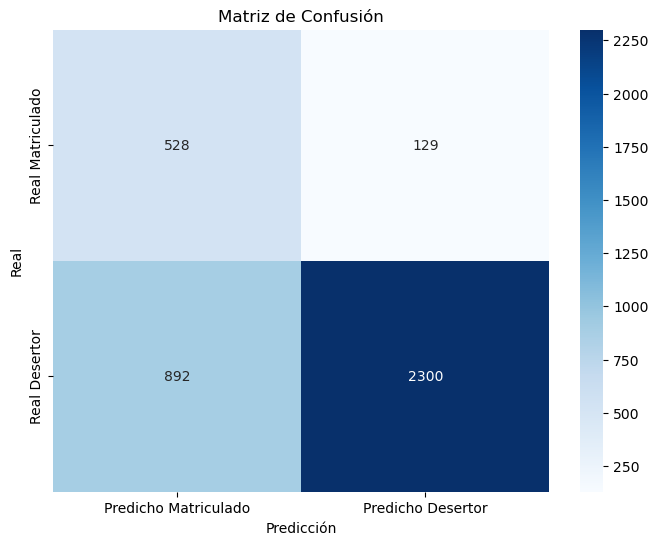

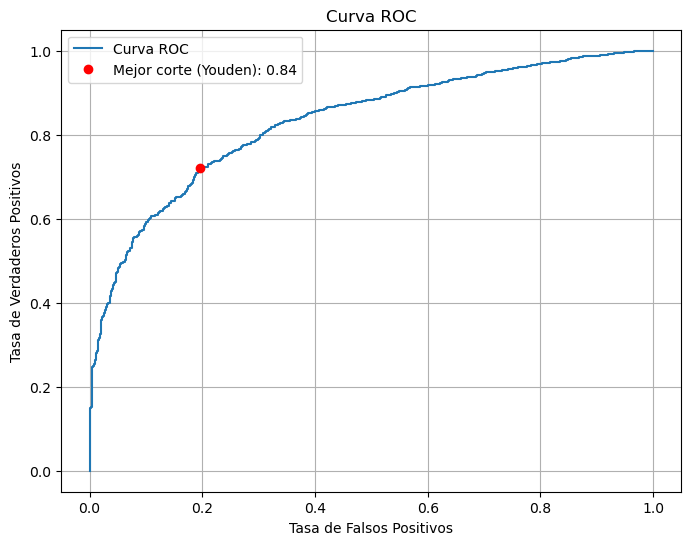


 == Resultados para programa:  MAT1111 - CALCULO II == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos → 0.00% válidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']

[Filtrado] Se eliminaron 0 filas con NaN en ['Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']
Columnas a usar (12): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos'] 
  Numero de filas a tener en cuenta: 3927
programa                 category
sexo                     category
procedencia_categoria    category
profesor_codigo          category
dtype: object
[OneHot] Columna 'programa' → eliminada aleatoriamente 'prog

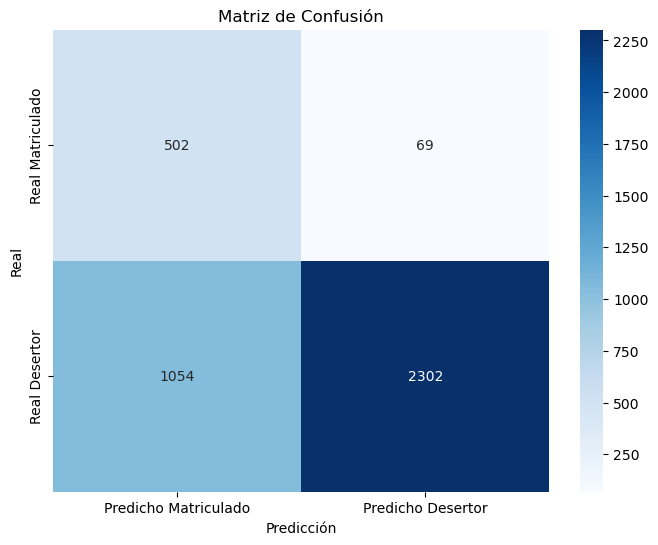

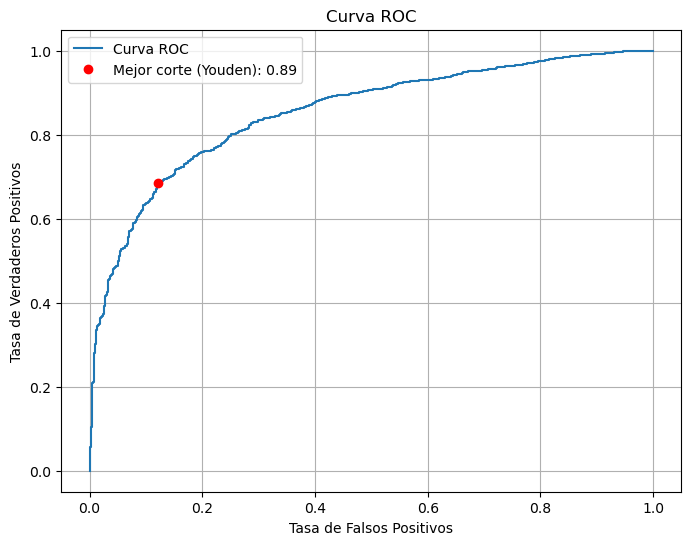


 == Resultados para programa:  EST7042 - ANÁLISIS  DE DATOS EN INGEN I == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos → 94.92% válidos → nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']

[Filtrado] Se eliminaron 141 filas con NaN en ['Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']
Columnas a usar (14): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos'] 
  Numero de filas a tener en cuenta: 2633


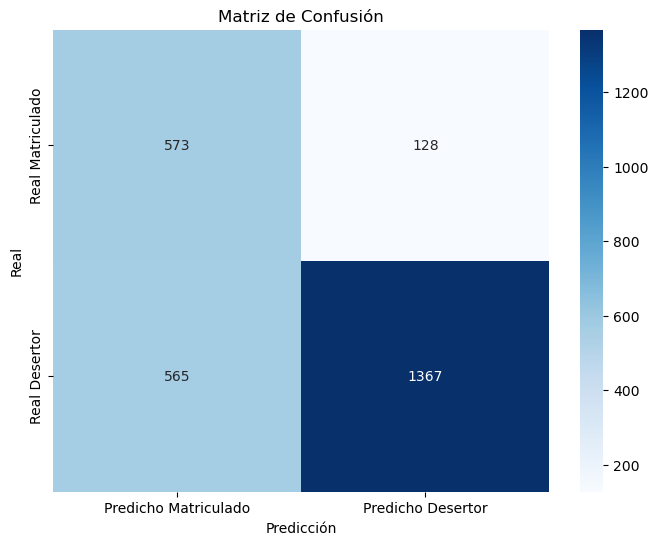

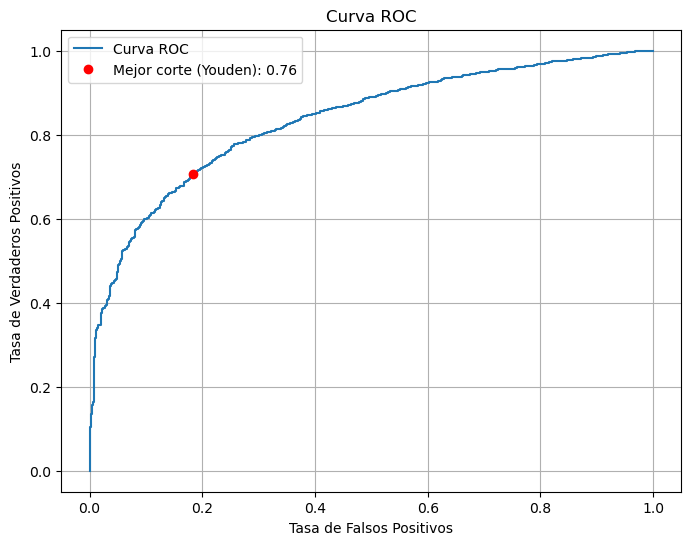


 == Resultados para programa:  IST2089 - ALGORITMIA Y PROGRAMACIÓN II == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos → 0.00% válidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_algoritmia_y_programacion_i_Intentos', 'Prereq_algoritmia_y_programacion_i_Nota']

[Filtrado] Se eliminaron 0 filas con NaN en ['Prereq_algoritmia_y_programacion_i_Intentos', 'Prereq_algoritmia_y_programacion_i_Nota']
Columnas a usar (12): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_algoritmia_y_programacion_i_Intentos', 'Prereq_algoritmia_y_programacion_i_Nota'] 
  Numero de filas a tener en cuenta: 1163
programa                 category
sexo                     category
procedencia_cate

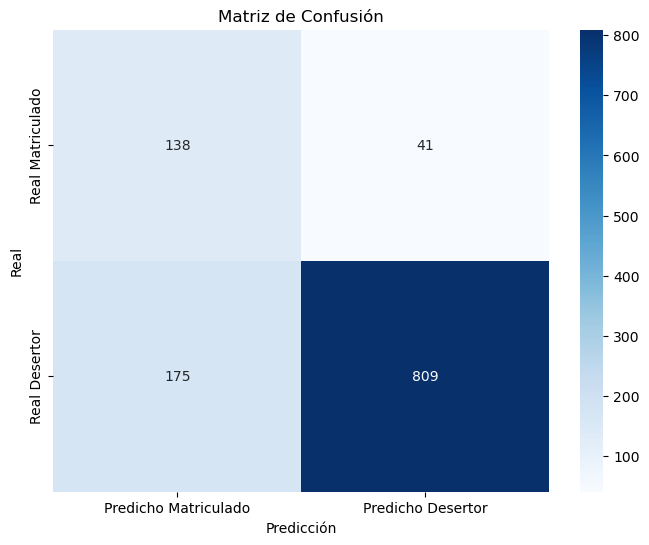

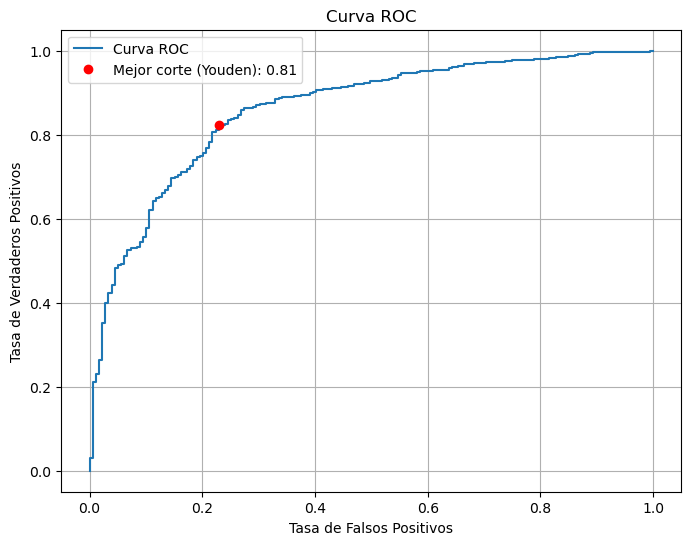


 == Resultados para programa:  MAT4011 - ECUACIONES DIFERENCIALES == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos → 94.43% válidos → nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']

[Filtrado] Se eliminaron 177 filas con NaN en ['Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']
Columnas a usar (14): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos'] 
  Numero de filas a tener en cuenta: 2999
progr

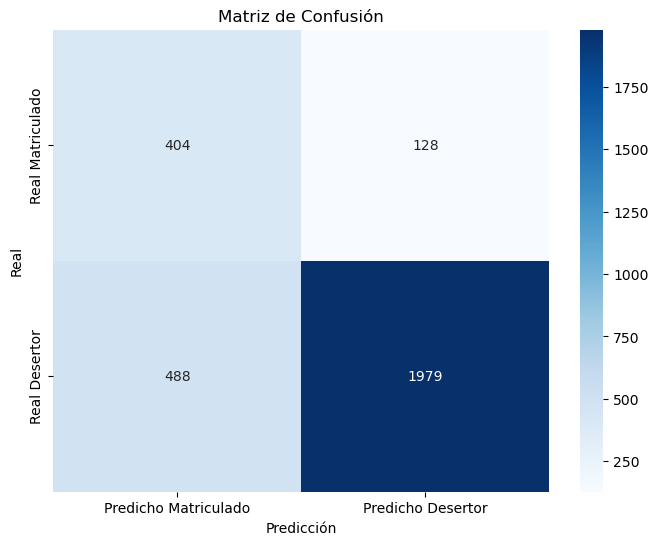

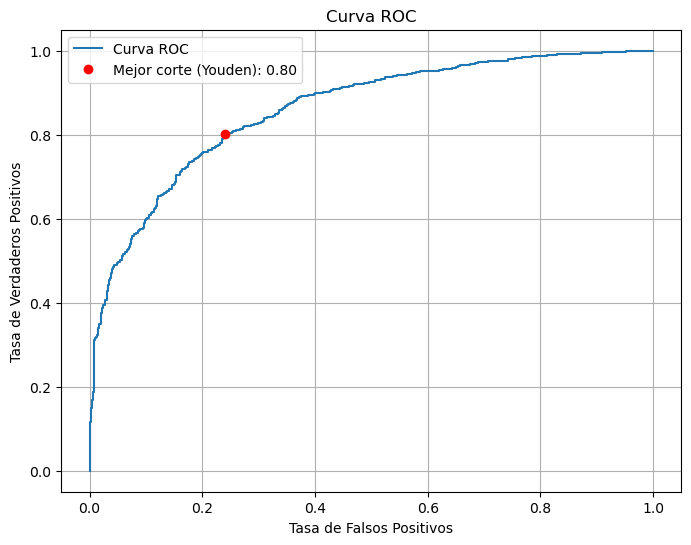


 == Resultados para programa:  IBA4032 - ESTÁTICA == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos → 94.29% válidos → nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']

[Filtrado] Se eliminaron 118 filas con NaN en ['Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']
Columnas a usar (14): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos'] 
  Numero de filas a tener en cuen

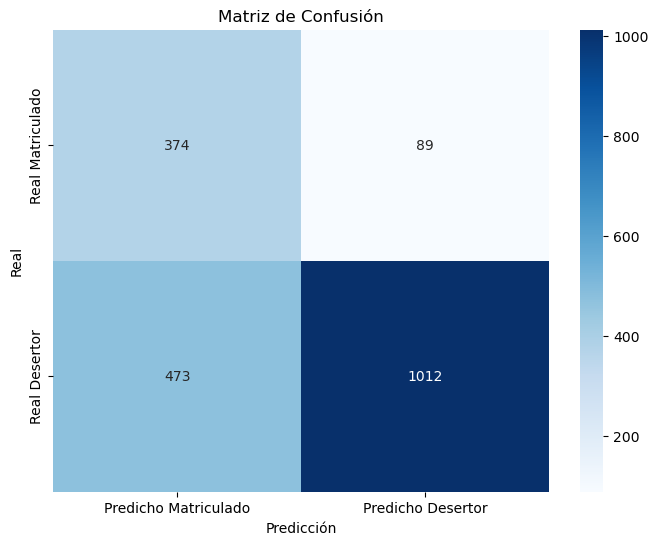

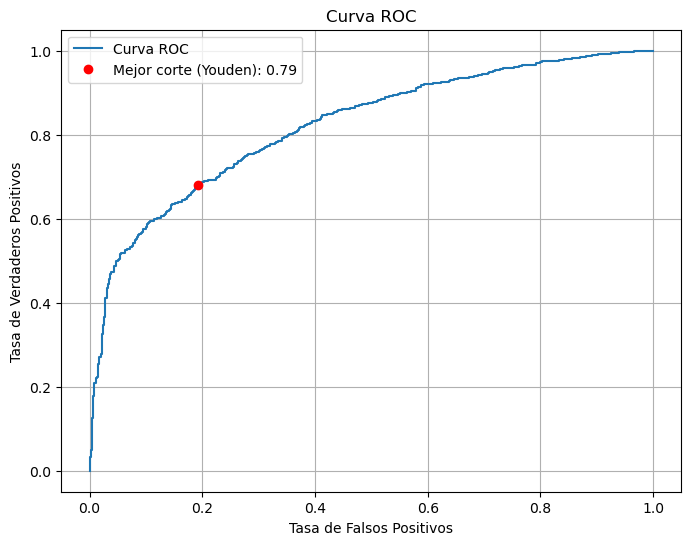


 == Resultados para programa:  MAT4258 - CALCULO II (ANEC) == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Excluido] Prereq_2_Nota y Prereq_2_Intentos → 0.00% válidos (<80%)
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_i_anec_Nota', 'Prereq_calculo_i_anec_Intentos']

[Filtrado] Se eliminaron 0 filas con NaN en ['Prereq_calculo_i_anec_Nota', 'Prereq_calculo_i_anec_Intentos']
Columnas a usar (12): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_calculo_i_anec_Nota', 'Prereq_calculo_i_anec_Intentos'] 
  Numero de filas a tener en cuenta: 2361
programa                 category
sexo                     category
procedencia_categoria    category
profesor_codigo          category
dtype: object
[OneHot] Columna 'progr

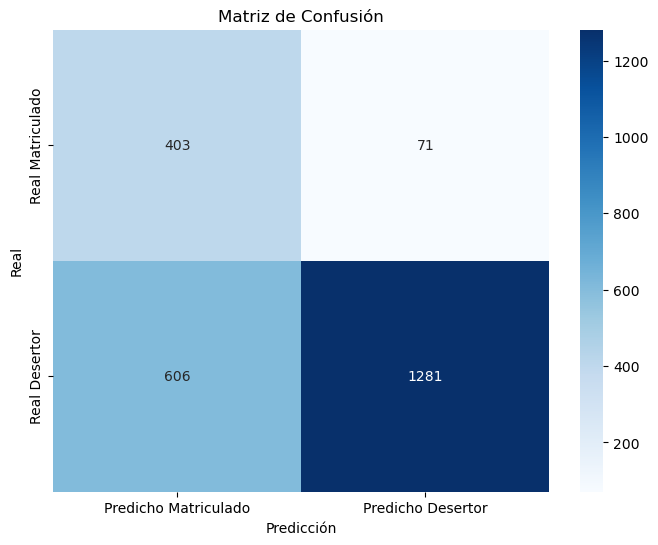

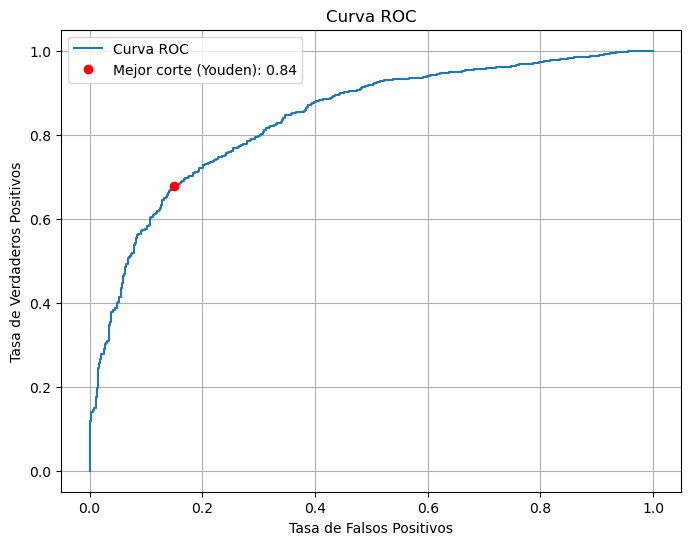


 == Resultados para programa:  MAT4260 - CALCULO III (ANEC) == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos → 93.67% válidos → nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_ii_anec_Nota', 'Prereq_calculo_ii_anec_Intentos', 'Prereq_calculo_i_anec_Nota', 'Prereq_calculo_i_anec_Intentos']

[Filtrado] Se eliminaron 126 filas con NaN en ['Prereq_calculo_ii_anec_Nota', 'Prereq_calculo_ii_anec_Intentos', 'Prereq_calculo_i_anec_Nota', 'Prereq_calculo_i_anec_Intentos']
Columnas a usar (14): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_calculo_ii_anec_Nota', 'Prereq_calculo_ii_anec_Intentos', 'Prereq_calculo_i_anec_Nota', 'Prereq_calculo_i_anec_Inten

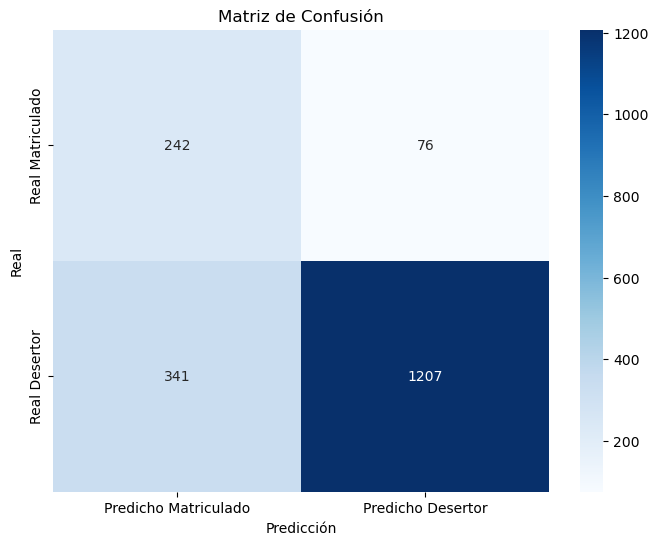

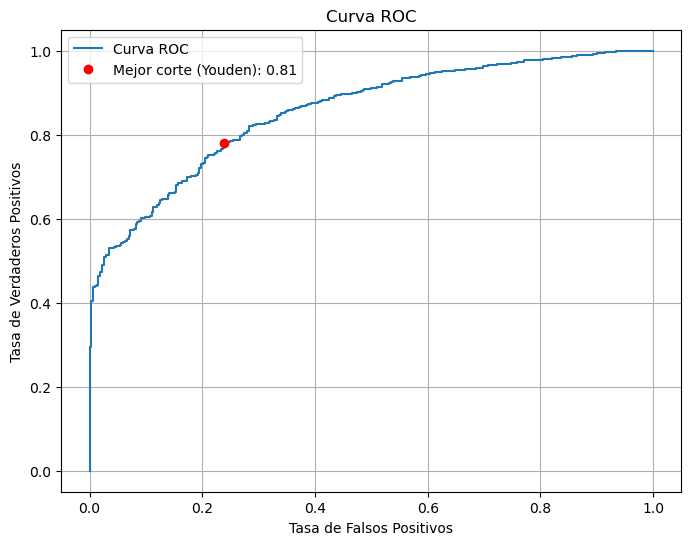


 == Resultados para programa:  FIS1033 - FISICA ELECTRICIDAD == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos → 100.00% válidos → nuevas columnas creadas.
[Incluido] Prereq_3_Nota y Prereq_3_Intentos → 94.64% válidos → nuevas columnas creadas.

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']

[Filtrado] Se eliminaron 154 filas con NaN en ['Prereq_calculo_ii_Nota', 'Prereq_calculo_ii_Intentos', 'Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']
Columnas a usar (16): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_c

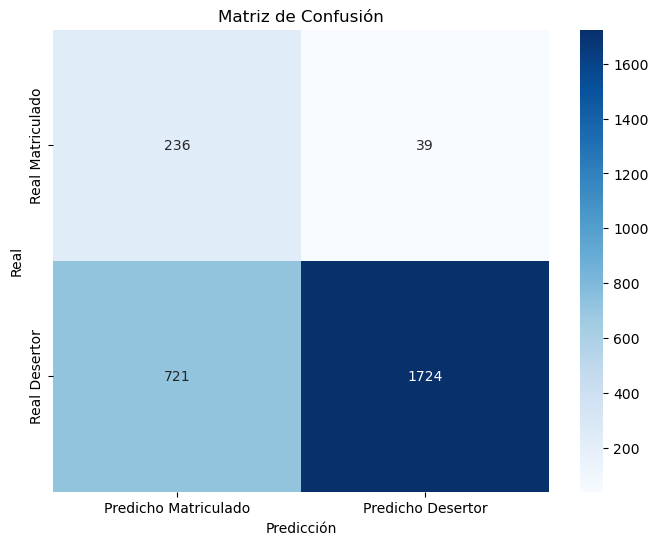

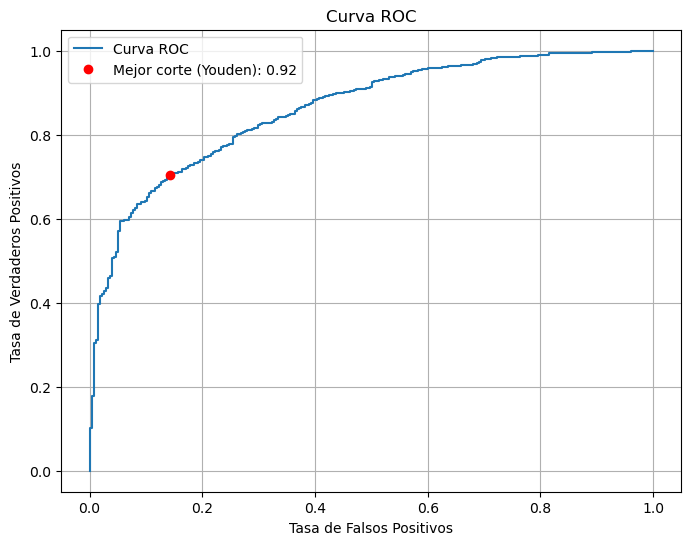


 == Resultados para programa:  FIS1043 - FISICA CALOR ONDAS == 

[Incluido] Prereq_1_Nota y Prereq_1_Intentos → 100.00% válidos → nuevas columnas creadas.
[Incluido] Prereq_2_Nota y Prereq_2_Intentos → 100.00% válidos → nuevas columnas creadas.
[Excluido] Prereq_3_Nota y Prereq_3_Intentos → 0.00% válidos (<80%)

Resumen final:
Columnas nuevas seleccionadas: ['Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']

[Filtrado] Se eliminaron 0 filas con NaN en ['Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos']
Columnas a usar (14): ['repitencia_prof_ref', 'programa', 'profesor_codigo', 'pga_inicial', 'promedio_sem_t1', 'sexo', 'asistencia_cree_t1', 'procedencia_categoria', 'edad_curso', 'num_intentos_asignatura', 'Prereq_fisica_mecanica_Nota', 'Prereq_fisica_mecanica_Intentos', 'Prereq_calculo_i_Nota', 'Prereq_calculo_i_Intentos'] 
  Numero de filas a tene

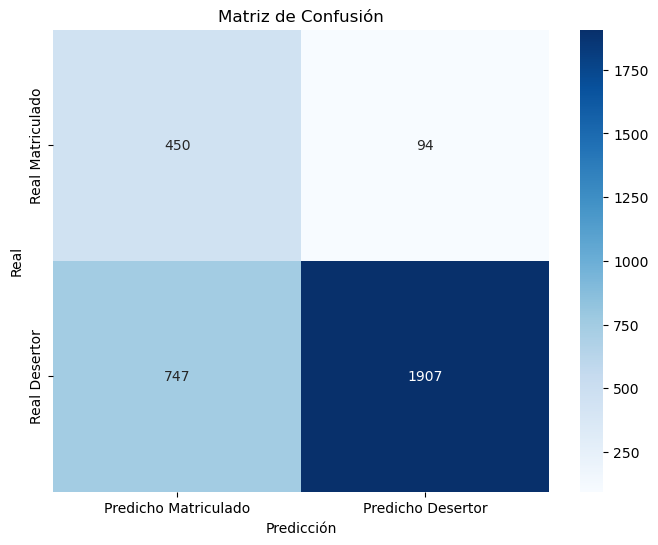

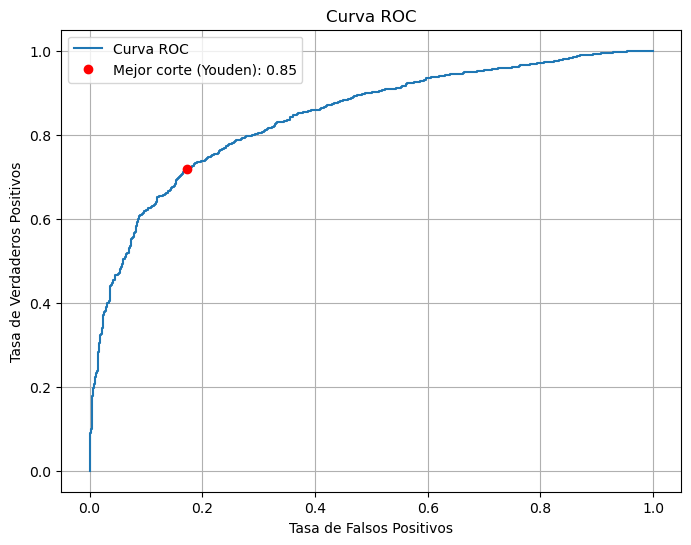

In [30]:
col_usar=[]
var_objetivo=""
col_dummies_creadas=[]

for asig in asig_a_usar:
    nombre_asig = df_usar[df_usar["Cod materia curso"] == asig]["Descripcion_Materia"].iloc[0]
    print(f"\n == Resultados para programa:  {(asig)} - {(nombre_asig)} == \n")
    df_usar_filtrado = df_usar[df_usar["Cod materia curso"] == asig].copy()
    col_dummies_creadas=[]
    
    #La variable objetivo esta definida dentro de la función renombrar_columnas
    df_usar_filtrado,col_usar,var_objetivo=renombrar_columnas(df_usar_filtrado)

    #df_usar_filtrado, lista_prereq_usar= columnas_prereq_validas(df_usar_filtrado, 0.8)
    df_usar_filtrado, lista_prereq_usar= columnas_prereq_validas_ext(df_usar_filtrado, df_historial_asignaturas_nombres,0.8)
    
    col_usar = col_usar + lista_prereq_usar

    print(f"Columnas a usar ({len(col_usar)}): {col_usar} \n  Numero de filas a tener en cuenta: {len(df_usar_filtrado)}")

    #print(df_usar_filtrado.columns.values.tolist())

    cols_to_category = [
        "programa",
        "sexo",
        "procedencia_categoria",
        "profesor_codigo"
    ]


    df_usar_filtrado=cambiar_a_category(df_usar_filtrado, cols_to_category)

    df_usar_filtrado_dummies,col_dummies_creadas = aplicar_one_hot(df_usar_filtrado, cols_to_category, True)

    col_usar = (col_usar + col_dummies_creadas )

    #cols_to_category = cols_to_category+ [
    #    "profesor_codigo_241","profesor_codigo_455","profesor_codigo_456","profesor_codigo_870","profesor_codigo_911","profesor_codigo_912","profesor_codigo_1100","profesor_codigo_1365","profesor_codigo_1526","profesor_codigo_1643","profesor_codigo_1959","profesor_codigo_2783","profesor_codigo_2918","profesor_codigo_3432","profesor_codigo_3434","profesor_codigo_3508","profesor_codigo_3512","profesor_codigo_3605","profesor_codigo_3667","profesor_codigo_3669","profesor_codigo_3670","profesor_codigo_3752","profesor_codigo_3796","profesor_codigo_3837","profesor_codigo_3838","profesor_codigo_3972","profesor_codigo_4419","profesor_codigo_4839","profesor_codigo_4938","profesor_codigo_5250","profesor_codigo_5252","profesor_codigo_5253","profesor_codigo_5258","profesor_codigo_5259","profesor_codigo_5635","profesor_codigo_5758","profesor_codigo_5759","profesor_codigo_5760","profesor_codigo_5763","profesor_codigo_5764","profesor_codigo_5765","profesor_codigo_5766","profesor_codigo_5767","profesor_codigo_5768","profesor_codigo_5932" ]
    col_usar = [c for c in col_usar if c not in cols_to_category]

    x = df_usar_filtrado_dummies[col_usar]
    x = aplicar_minmax_scaling(x)
    x = sm.add_constant(x)  # Agregar constante para el intercepto
    y = df_usar_filtrado_dummies[var_objetivo]

    df_logit = run_logit_model_general(df_usar_filtrado_dummies, x, y,"_"+asig)
